### Predicting the Future with Exponential Smoothing

The Concept: How much do you remember?

Imagine you are trying to guess what your friend will wear to school tomorrow.

Simple Average: You look at everything they wore for the last 3 years and take an average. (Wait, they wore diapers 3 years ago! That's not helpful).

Exponential Smoothing: You give more importance to what they wore yesterday and the day before, and less importance to what they wore last month.

It’s like having a memory that slowly fades. The "Smoothing" part just means we're ignoring the tiny, random zig-zags in the data to see the big trend.

### Setup and Creating our "Sales" Data
Let's pretend we are tracking how many Lemonades a stand sells over 20 days.

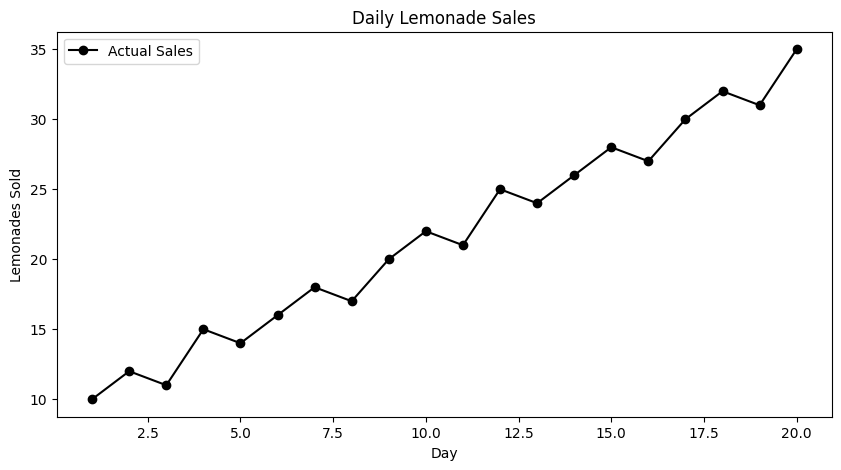

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# 1. Create 20 days of lemonade sales with some random 'noise' (wobbles)
np.random.seed(42)
days = np.arange(1, 21)
sales = [10, 12, 11, 15, 14, 16, 18, 17, 20, 22, 21, 25, 24, 26, 28, 27, 30, 32, 31, 35]

# Turn it into a Pandas series (a fancy list for math)
data = pd.Series(sales)

plt.figure(figsize=(10, 5))
plt.plot(days, sales, marker='o', label="Actual Sales", color="black")
plt.title("Daily Lemonade Sales")
plt.xlabel("Day")
plt.ylabel("Lemonades Sold")
plt.legend()
plt.show()

 ### Applying Exponential Smoothing
 
 We use a variable called Alpha (a).
 * If alpha is high (0.8): The computer has a "Fresh Memory" (it cares mostly about yesterday).
 * If alpha is low (0.2): The computer has a "Long Memory" (it looks at the whole history).

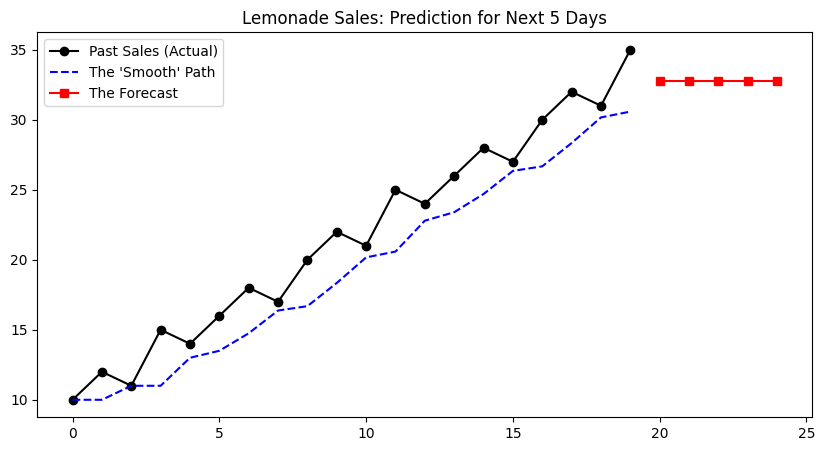

In [2]:
# 1. Create the model
model = SimpleExpSmoothing(data)

# 2. Fit the model (The computer calculates the 'smooth' line)
# We will use a 'smoothing_level' of 0.5 (a mix of new and old info)
fit = model.fit(smoothing_level=0.5, optimized=False)

# 3. Forecast the next 5 days
forecast = fit.forecast(5)

# 4. Combine them for a plot
plt.figure(figsize=(10, 5))
plt.plot(data, marker="o", label="Past Sales (Actual)", color="black")
plt.plot(fit.fittedvalues, label="The 'Smooth' Path", color="blue", linestyle="--")
plt.plot(np.arange(20, 25), forecast, marker="s", label="The Forecast", color="red")

plt.title("Lemonade Sales: Prediction for Next 5 Days")
plt.legend()
plt.show()

### Why does the forecast look like a flat line?

In this simple version (Simple Exponential Smoothing), the computer says: "The best guess for tomorrow is a weighted version of yesterday."

If you want the computer to see the UPWARD TREND (the fact that sales are growing every day), you would use a "Level 2" version called Holt’s Linear Trend.

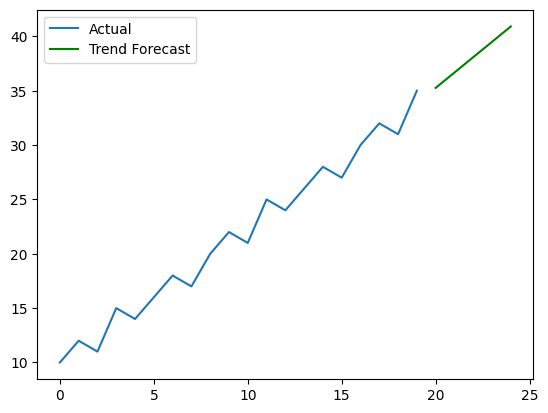

In [3]:
from statsmodels.tsa.holtwinters import Holt

# This version looks at the LEVEL (sales) AND the TREND (growth)
holt_model = Holt(data).fit()
holt_forecast = holt_model.forecast(5)

plt.plot(data, label="Actual")
plt.plot(np.arange(20, 25), holt_forecast, color="green", label="Trend Forecast")
plt.legend()
plt.show()

Conclusion: 
* Simple Smoothing: Best for things that stay mostly the same (like how many milk cartons a school needs).
* Trend Smoothing (Holt's): Best for things that are growing or shrinking (like a new YouTube channel's views).
* Alpha (a): The "Memory Dial." High alpha = reactive. Low alpha = stable.